# Load ETAS vs thinning ensemble realizations

Load forecast catalogs produced by `runnable_code/catalog_california_etas_vs_thinning_ensemble.py`.

Each realization lives under `<ensemble_dir>/seed_<seed>/` with:
- `etas_catalog.csv`
- `thinning_catalog.csv`
- `summary.csv`

Legacy layouts (`realizations/seed_<seed>/` or `inv_*_seed<start>/` folders) are also discovered when loading.

Set **`ENSEMBLE_DIR`** below, then choose how many realizations to load:
- **`all`** (default) — every `seed_*` folder
- **`first_n`** — the first *n* seeds in sorted order
- **`seeds`** — an explicit list of integer seeds

In [17]:
%matplotlib inline

from __future__ import annotations

import json
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ETAS_COLOR = "seagreen"
THINNING_COLOR = "indianred"


In [18]:
def find_repo_root() -> Path:
    """Locate etas repo root even if the kernel cwd is not the repo."""
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "catalog_california_etas_vs_thinning_ensemble.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Open this notebook from the etas checkout "
        "and/or set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()
ENSEMBLES_ROOT = REPO_ROOT / "outputs/catalog_etas_vs_thinning/ensembles"

# Explicit ensemble folder, or None = auto-pick newest inv_* dir that has seed_* data
ENSEMBLE_DIR: Path | None = ENSEMBLES_ROOT / "inv_c0b4eb6d6e4a24f1"

# --- which realizations to load ---
LOAD_MODE: Literal["all", "first_n", "seeds"] = "all"
FIRST_N: int = 5          # used when LOAD_MODE == "first_n"
SEEDS: list[int] = [100]  # used when LOAD_MODE == "seeds"


In [19]:
def list_ensemble_dirs(ensembles_root: Path) -> list[Path]:
    """``inv_*`` folders under ``ensembles_root`` that contain at least one seed."""
    if not ensembles_root.is_dir():
        return []
    found: list[Path] = []
    for path in ensembles_root.iterdir():
        if not path.is_dir() or not path.name.startswith("inv_"):
            continue
        try:
            discover_realization_seeds(path)
        except FileNotFoundError:
            continue
        found.append(path)
    return sorted(found, key=lambda p: p.stat().st_mtime, reverse=True)


def resolve_ensemble_dir(explicit: Path | None, ensembles_root: Path) -> Path:
    if explicit is not None:
        path = explicit.expanduser()
        if not path.is_absolute():
            path = (REPO_ROOT / path).resolve()
        else:
            path = path.resolve()
        if path.is_dir():
            return path

    candidates = list_ensemble_dirs(ensembles_root)
    lines = "\n".join(f"  - {p}" for p in candidates) if candidates else "  (none)"
    if explicit is not None:
        raise FileNotFoundError(
            f"Ensemble directory not found: {explicit}\n"
            f"REPO_ROOT={REPO_ROOT}\n"
            f"ENSEMBLES_ROOT exists={ensembles_root.is_dir()}\n"
            f"Available ensemble dirs with seed_* data:\n{lines}"
        )
    if not candidates:
        raise FileNotFoundError(
            f"No ensemble output under {ensembles_root.resolve()}.\n"
            "Run runnable_code/catalog_california_etas_vs_thinning_ensemble.py first."
        )
    chosen = candidates[0]
    print(f"Auto-selected ensemble dir: {chosen}")
    return chosen


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    """Sorted seeds from ``seed_<seed>/`` (flat or legacy ``realizations/`` layout)."""
    seeds: set[int] = set()
    if not ensemble_dir.is_dir():
        raise FileNotFoundError(f"Not a directory: {ensemble_dir}")

    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))

    legacy = ensemble_dir / "realizations"
    if legacy.is_dir():
        for path in legacy.iterdir():
            if path.is_dir() and path.name.startswith("seed_"):
                seeds.add(int(path.name.removeprefix("seed_")))

    if not seeds:
        raise FileNotFoundError(
            f"No seed_* folders under {ensemble_dir} (or {legacy})"
        )
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1 when LOAD_MODE is 'first_n'")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty when LOAD_MODE is 'seeds'")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def _realization_dir_for_seed(ensemble_dir: Path, seed: int) -> Path:
    flat = ensemble_dir / f"seed_{seed}"
    legacy = ensemble_dir / "realizations" / f"seed_{seed}"
    if flat.is_dir():
        return flat
    if legacy.is_dir():
        return legacy
    return flat


def load_realization_catalogs(ensemble_dir: Path, seed: int) -> dict[str, pd.DataFrame]:
    run_dir = _realization_dir_for_seed(ensemble_dir, seed)
    etas_path = run_dir / "etas_catalog.csv"
    thin_path = run_dir / "thinning_catalog.csv"
    for path in (etas_path, thin_path):
        if not path.is_file():
            raise FileNotFoundError(path)
    etas = pd.read_csv(etas_path)
    thinning = pd.read_csv(thin_path)
    for df in (etas, thinning):
        if "dt_days" in df.columns:
            df["dt_days"] = pd.to_numeric(df["dt_days"], errors="coerce")
        if "m" in df.columns:
            df["m"] = pd.to_numeric(df["m"], errors="coerce")
    return {"etas": etas, "thinning": thinning}


def load_ensemble_realizations(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, dict[str, pd.DataFrame]], pd.DataFrame, dict]:
    """Return (catalogs_by_seed, metrics_df, meta)."""
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)

    meta_path = ensemble_dir / "ensemble_meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.is_file() else {}

    metrics_path = ensemble_dir / "per_realization_metrics.csv"
    metrics_df = pd.read_csv(metrics_path) if metrics_path.is_file() else pd.DataFrame()
    if not metrics_df.empty and "seed" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seed"].isin(selected)].reset_index(drop=True)

    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]] = {}
    for seed in selected:
        catalogs_by_seed[seed] = load_realization_catalogs(ensemble_dir, seed)

    return catalogs_by_seed, metrics_df, meta


In [20]:
ensemble_dir = resolve_ensemble_dir(ENSEMBLE_DIR, ENSEMBLES_ROOT)

available_seeds = discover_realization_seeds(ensemble_dir)
selected_seeds = select_seeds(
    available_seeds,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)

catalogs_by_seed, metrics_df, meta = load_ensemble_realizations(
    ensemble_dir,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**Ensemble dir:** `{ensemble_dir}`"))
display(Markdown(f"**Available seeds:** {available_seeds}"))
display(Markdown(f"**Loaded seeds ({LOAD_MODE}):** {selected_seeds}"))
if meta:
    display(Markdown(
        f"Forecast window: `{meta.get('timewindow_end')}` → `{meta.get('testwindow_end')}` "
        f"({meta.get('forecast_days', '?')} days)"
    ))

metrics_df


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**Ensemble dir:** `/home/neriberman/Repos/etas/outputs/catalog_etas_vs_thinning/ensembles/inv_c0b4eb6d6e4a24f1`

**Available seeds:** [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

**Loaded seeds (all):** [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

""


In [21]:
# Convenience views for interactive analysis
etas_by_seed = {seed: catalogs["etas"] for seed, catalogs in catalogs_by_seed.items()}
thinning_by_seed = {seed: catalogs["thinning"] for seed, catalogs in catalogs_by_seed.items()}

# Example: peek at one realization
example_seed = selected_seeds[0]
print(f"ETAS catalog (seed={example_seed}), n={len(etas_by_seed[example_seed])}")
display(etas_by_seed[example_seed].head())
print(f"Thinning catalog (seed={example_seed}), n={len(thinning_by_seed[example_seed])}")
display(thinning_by_seed[example_seed].head())


ETAS catalog (seed=0), n=1453


,G,angle,degree_lat,degree_lon,evt_id,expected_n_aftershocks,gen_0_parent,generation,is_background,l_hat,...,source_to_end_time_distance,time,time_delta,xi_plus_1,t,dt_days,x,y,m,event_source
0,NaN,0.480341,111.318845,90.280310,NaN,1.222251,3295,1,False,NaN,...,NaN,2007-01-01 19:27:00.111997607,11.504917,1.0,13514.810418,0.842001,-115.067507,35.836085,4.506801,triggered
1,NaN,0.821762,111.318845,90.245266,NaN,0.716669,3295,2,False,NaN,...,NaN,2007-01-03 07:36:27.843009724,1.506571,1.0,13516.316989,2.348572,-115.052466,35.847422,4.012160,triggered
2,NaN,5.203896,111.318845,90.232368,NaN,0.888580,3295,3,False,NaN,...,NaN,2007-01-03 21:31:15.863140930,0.579722,1.0,13516.896711,2.928294,-115.078384,35.858669,4.211385,triggered
3,NaN,NaN,NaN,NaN,3305.0,0.512853,1,0,True,NaN,...,NaN,2007-01-04 09:31:24.718394000,NaN,1.0,13517.396814,3.428396,-120.936228,34.174271,3.702104,background
4,NaN,3.172926,111.318845,91.139800,NaN,0.480248,3293,1,False,NaN,...,NaN,2007-01-05 05:52:38.999385465,15.060070,1.0,13518.244896,4.276478,-118.294272,35.039750,3.641241,triggered


Thinning catalog (seed=0), n=2127


,t,x,y,m,event_source,dt_days
0,13515.833702,-115.381527,35.808598,3.761060,triggered,1.865285
1,13516.874540,-117.105629,33.451777,4.440460,triggered,2.906122
2,13517.558170,-118.482190,34.679199,3.783738,triggered,3.589753
3,13517.755393,-117.114086,33.470902,4.049776,triggered,3.786976
4,13518.013275,-117.092267,33.475529,3.610240,triggered,4.044858


## Example: accumulated statistics — ensemble cumulative count N(t)

For each loaded realization, build the step-function cumulative event count versus days since forecast start, resample on a common time grid, then plot the **mean** with the **25th–75th percentile** band across realizations for ETAS and thinning.

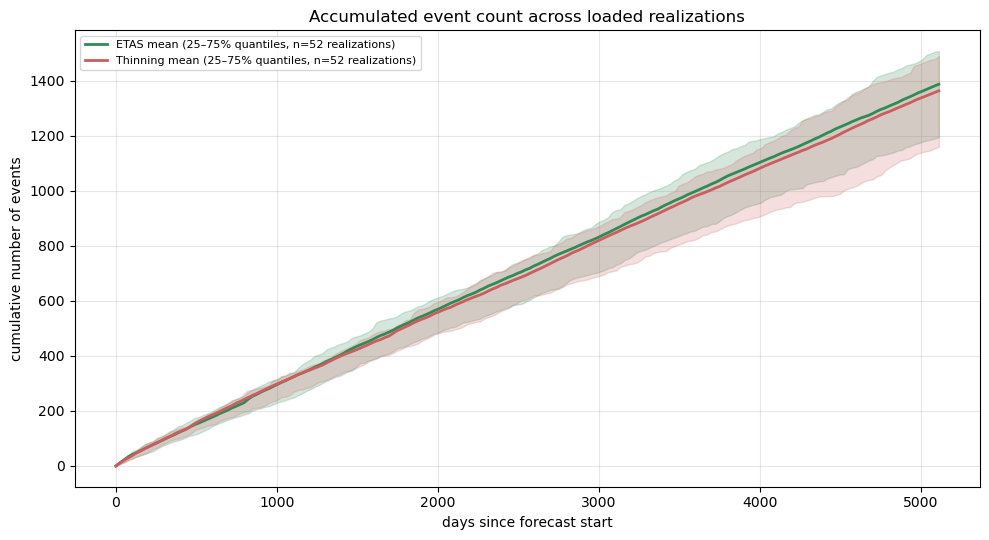

In [22]:
def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    """Step-function cumulative count N(t) evaluated on ``t_grid`` (days since forecast start)."""
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


forecast_days = float(meta.get("forecast_days", np.nan))
if not np.isfinite(forecast_days):
    all_dt = np.concatenate([
        df["dt_days"].to_numpy()
        for catalogs in catalogs_by_seed.values()
        for df in catalogs.values()
    ])
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0

t_grid = np.linspace(0.0, forecast_days, 200)
etas_curves = np.vstack([
    cumulative_on_grid(etas_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])
thin_curves = np.vstack([
    cumulative_on_grid(thinning_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])

fig, ax = plt.subplots(figsize=(10, 5.5))
pale_colors = {"ETAS": "#519463", "Thinning": "#E9A8A8"}

# for curves, pale in [
#     (etas_curves, pale_colors["ETAS"]),
#     (thin_curves, pale_colors["Thinning"]),
# ]:
#     for curve in curves:
#         ax.plot(t_grid, curve, color=pale, lw=1.1, alpha=0.6, zorder=1)

for label, arr, color in [
    ("ETAS", etas_curves, ETAS_COLOR),
    ("Thinning", thin_curves, THINNING_COLOR),
]:
    mean = arr.mean(axis=0)
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
    else:
        q25 = q75 = mean
    ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
    ax.plot(
        t_grid,
        mean,
        color=color,
        lw=2.0,
        zorder=3,
        label=f"{label} mean (25–75% quantiles, n={arr.shape[0]} realizations)",
    )

ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events")
ax.set_title("Accumulated event count across loaded realizations")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


In [23]:
# Optional: summary boxplots from per-realization metrics (loaded subset only)
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].boxplot(
        [metrics_df["etas_n_events"], metrics_df["thinning_n_events"]],
        tick_labels=["ETAS", "Thinning"],
    )
    axes[0].set_ylabel("events in forecast window")
    axes[0].set_title("Event counts")
    axes[0].grid(True, alpha=0.3, axis="y")

    axes[1].scatter(
        metrics_df["etas_n_events"],
        metrics_df["thinning_n_events"],
        c=metrics_df["seed"],
        cmap="viridis",
        s=50,
        edgecolors="black",
        linewidths=0.3,
    )
    lo = min(metrics_df["etas_n_events"].min(), metrics_df["thinning_n_events"].min())
    hi = max(metrics_df["etas_n_events"].max(), metrics_df["thinning_n_events"].max())
    axes[1].plot([lo, hi], [lo, hi], "k--", lw=1.0, alpha=0.6)
    axes[1].set_xlabel("ETAS event count")
    axes[1].set_ylabel("Thinning event count")
    axes[1].set_title("Per-realization comparison")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"Loaded realizations: seeds {selected_seeds}", fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print("No per_realization_metrics.csv — skip summary plots.")


No per_realization_metrics.csv — skip summary plots.


In [24]:
import csep
from csep.core.catalogs import CSEPCatalog
from csep.core.forecasts import CatalogForecast
from csep.core.regions import california_relm_region, create_space_magnitude_region
from csep.utils.constants import CSEP_MW_BINS
from csep.utils.time_utils import datetime_to_utc_epoch


## CSEP expected rates from catalog forecasts

Treat each loaded realization as one synthetic catalog, wrap them in a `CatalogForecast`, and call `get_expected_rates()`:

1. Define a space–magnitude region (California RELM grid + CSEP magnitude bins).
2. Convert each pandas catalog to `CSEPCatalog`.
3. Bin every realization with `spatial_magnitude_counts()`, sum across realizations, divide by `n_cat`.

This mirrors `examples/tutorials/working_with_catalog_forecasts.py` in PyCSEP.

In [25]:
def _parse_forecast_window(meta: dict) -> tuple | None:
    """Return (start, end) if meta has both window endpoints, else None."""
    if not meta.get("timewindow_end") or not meta.get("testwindow_end"):
        return None
    start = pd.to_datetime(meta["timewindow_end"], utc=True).to_pydatetime()
    end = pd.to_datetime(meta["testwindow_end"], utc=True).to_pydatetime()
    return start, end


def forecast_window_from_meta(
    meta: dict,
    *,
    ensemble_dir: Path,
    seed: int,
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
) -> tuple:
    """Forecast interval: timewindow_end → testwindow_end (UTC-aware datetimes)."""
    window = _parse_forecast_window(meta)
    if window is not None:
        return window

    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    if realization_meta_path.is_file():
        realization_meta = json.loads(realization_meta_path.read_text(encoding="utf-8"))
        window = _parse_forecast_window(realization_meta)
        if window is not None:
            print(f"Forecast window from {realization_meta_path.name} (seed={seed})")
            return window

    all_times = []
    for catalogs in catalogs_by_seed.values():
        for df in catalogs.values():
            if df.empty:
                continue
            if "time" in df.columns:
                all_times.append(pd.to_datetime(df["time"], utc=True))
            elif "t" in df.columns:
                all_times.append(
                    pd.Timestamp("1970-01-01", tz="UTC")
                    + pd.to_timedelta(df["t"], unit="D")
                )
    if all_times:
        times = pd.concat(all_times, ignore_index=True)
        print("Forecast window inferred from min/max event times in loaded catalogs")
        return times.min().to_pydatetime(), times.max().to_pydatetime()

    raise ValueError(
        "Could not determine forecast window: missing ensemble_meta.json, "
        "realization_meta.json, and catalog time columns."
    )


def _catalog_origin_time_epoch(df: pd.DataFrame) -> pd.Series:
    """Absolute event times as CSEP UTC epochs (ms)."""
    if "time" in df.columns:
        return pd.to_datetime(df["time"], utc=True).map(datetime_to_utc_epoch)
    if "t" in df.columns:
        epochs = pd.Timestamp("1970-01-01", tz="UTC") + pd.to_timedelta(df["t"], unit="D")
        return epochs.map(datetime_to_utc_epoch)
    raise KeyError("catalog needs a 'time' or 't' column for CSEP conversion")


def _catalog_coordinate_series(df: pd.DataFrame, *, primary: str, fallback: str) -> pd.Series:
    if primary in df.columns:
        return df[primary].astype(float)
    if fallback in df.columns:
        return df[fallback].astype(float)
    raise KeyError(f"catalog needs '{primary}' or '{fallback}'")


def dataframe_to_csep_catalog(
    df: pd.DataFrame,
    *,
    catalog_id: int,
    region,
) -> CSEPCatalog:
    """Map ensemble CSV columns to the CSEP catalog dtype."""
    csep_df = pd.DataFrame(
        {
            "id": [f"evt_{i}" for i in range(len(df))],
            "origin_time": _catalog_origin_time_epoch(df),
            "latitude": _catalog_coordinate_series(df, primary="latitude", fallback="y"),
            "longitude": _catalog_coordinate_series(df, primary="longitude", fallback="x"),
            "depth": np.zeros(len(df)),
            "magnitude": _catalog_coordinate_series(df, primary="magnitude", fallback="m"),
            "catalog_id": catalog_id,
        }
    )
    return CSEPCatalog.from_dataframe(csep_df, region=region)


def build_catalog_forecast(
    catalogs_by_seed: dict[int, pd.DataFrame],
    *,
    name: str,
    region,
    start_time,
    end_time,
    filter_spatial: bool = True,
) -> CatalogForecast:
    """One CatalogForecast from the loaded seed → catalog mapping."""
    seeds = sorted(catalogs_by_seed)
    catalogs = [
        dataframe_to_csep_catalog(catalogs_by_seed[seed], catalog_id=i, region=region)
        for i, seed in enumerate(seeds)
    ]
    return CatalogForecast(
        catalogs=catalogs,
        region=region,
        name=name,
        start_time=start_time,
        end_time=end_time,
        n_cat=len(catalogs),
        filter_spatial=filter_spatial,
        apply_filters=filter_spatial,
    )


# California RELM spatial grid with standard CSEP magnitude bin edges.
csep_region = create_space_magnitude_region(california_relm_region(), CSEP_MW_BINS)
forecast_start, forecast_end = forecast_window_from_meta(
    meta,
    ensemble_dir=ensemble_dir,
    seed=selected_seeds[0],
    catalogs_by_seed=catalogs_by_seed,
)

print(
    f"CSEP region: {csep_region.name}, "
    f"{csep_region.num_nodes} spatial cells, {len(csep_region.magnitudes)} magnitude bins"
)
print(f"Forecast window: {forecast_start} → {forecast_end}")


Forecast window from realization_meta.json (seed=0)
CSEP region: relm-california, 7682 spatial cells, 76 magnitude bins
Forecast window: 2007-01-01 00:00:00+00:00 → 2021-01-01 00:00:00+00:00


In [26]:
etas_catalog_forecast = build_catalog_forecast(
    etas_by_seed,
    name="ETAS ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)
thin_catalog_forecast = build_catalog_forecast(
    thinning_by_seed,
    name="Thinning ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)

etas_expected = etas_catalog_forecast.get_expected_rates(verbose=True)
thin_expected = thin_catalog_forecast.get_expected_rates(verbose=True)

etas_event_counts = etas_catalog_forecast.get_event_counts()
thin_event_counts = thin_catalog_forecast.get_event_counts()

summary = pd.DataFrame(
    {
        "method": ["ETAS", "Thinning"],
        "n_realizations": [etas_catalog_forecast.n_cat, thin_catalog_forecast.n_cat],
        "mean_events_per_catalog": [etas_event_counts.mean(), thin_event_counts.mean()],
        "mean_total_rate": [etas_expected.data.sum(), thin_expected.data.sum()],
    }
)
display(summary)
print(f"Expected-rate array shape (spatial × magnitude): {etas_expected.data.shape}")


Processed 1 catalogs in 0.001 seconds
Processed 2 catalogs in 0.004 seconds
Processed 3 catalogs in 0.005 seconds
Processed 4 catalogs in 0.006 seconds
Processed 5 catalogs in 0.008 seconds
Processed 6 catalogs in 0.009 seconds
Processed 7 catalogs in 0.010 seconds
Processed 8 catalogs in 0.011 seconds
Processed 9 catalogs in 0.013 seconds
Processed 10 catalogs in 0.014 seconds
Processed 20 catalogs in 0.024 seconds
Processed 30 catalogs in 0.034 seconds
Processed 40 catalogs in 0.045 seconds
Processed 50 catalogs in 0.055 seconds
Processed 1 catalogs in 0.001 seconds
Processed 2 catalogs in 0.003 seconds
Processed 3 catalogs in 0.004 seconds
Processed 4 catalogs in 0.005 seconds
Processed 5 catalogs in 0.007 seconds
Processed 6 catalogs in 0.008 seconds
Processed 7 catalogs in 0.009 seconds
Processed 8 catalogs in 0.010 seconds
Processed 9 catalogs in 0.012 seconds
Processed 10 catalogs in 0.013 seconds
Processed 20 catalogs in 0.023 seconds
Processed 30 catalogs in 0.033 seconds
Proc

,method,n_realizations,mean_events_per_catalog,mean_total_rate
0,ETAS,52,1128.326923,1128.326923
1,Thinning,52,1156.057692,1156.057692


Expected-rate array shape (spatial × magnitude): (7682, 76)


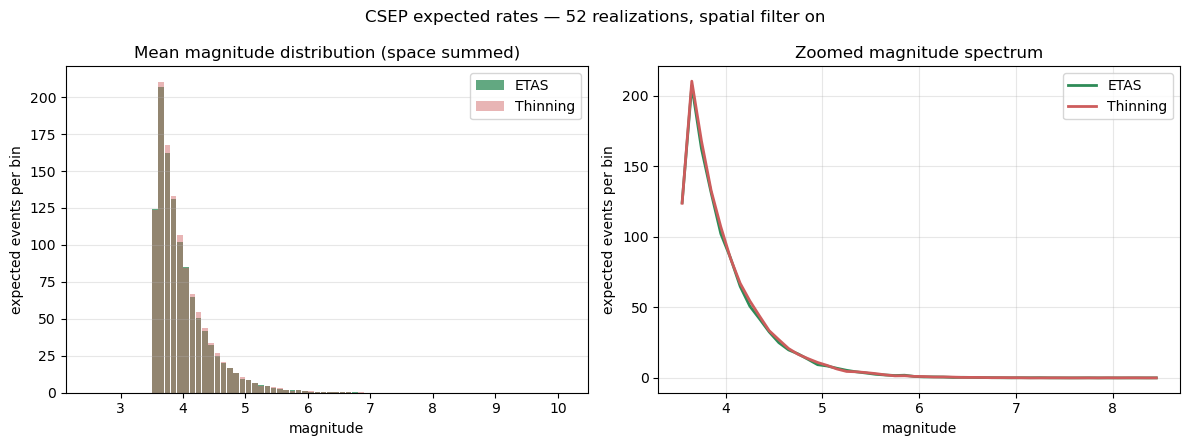

In [27]:
mag_bins = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_bins[1] - mag_bins[0]
mag_centers = mag_bins + dmw / 2

etas_mag_counts = etas_expected.magnitude_counts()
thin_mag_counts = thin_expected.magnitude_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    mag_centers,
    etas_mag_counts,
    width=dmw * 0.9,
    color=ETAS_COLOR,
    alpha=0.75,
    label="ETAS",
)
axes[0].bar(
    mag_centers,
    thin_mag_counts,
    width=dmw * 0.9,
    color=THINNING_COLOR,
    alpha=0.45,
    label="Thinning",
)
axes[0].set_xlabel("magnitude")
axes[0].set_ylabel("expected events per bin")
axes[0].set_title("Mean magnitude distribution (space summed)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

m_lo = max(2.5, float(min(etas_by_seed[s]["magnitude"].min() for s in selected_seeds)) - 0.1)
m_hi = min(8.5, float(max(etas_by_seed[s]["magnitude"].max() for s in selected_seeds)) + 0.1)
mask = (mag_centers >= m_lo) & (mag_centers <= m_hi)

axes[1].plot(mag_centers[mask], etas_mag_counts[mask], color=ETAS_COLOR, lw=2.0, label="ETAS")
axes[1].plot(mag_centers[mask], thin_mag_counts[mask], color=THINNING_COLOR, lw=2.0, label="Thinning")
axes[1].set_xlabel("magnitude")
axes[1].set_ylabel("expected events per bin")
axes[1].set_title("Zoomed magnitude spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f"CSEP expected rates — {len(selected_seeds)} realizations, spatial filter on",
    fontsize=12,
)
fig.tight_layout()
plt.show()


/tmp/ipykernel_1351198/3684855696.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


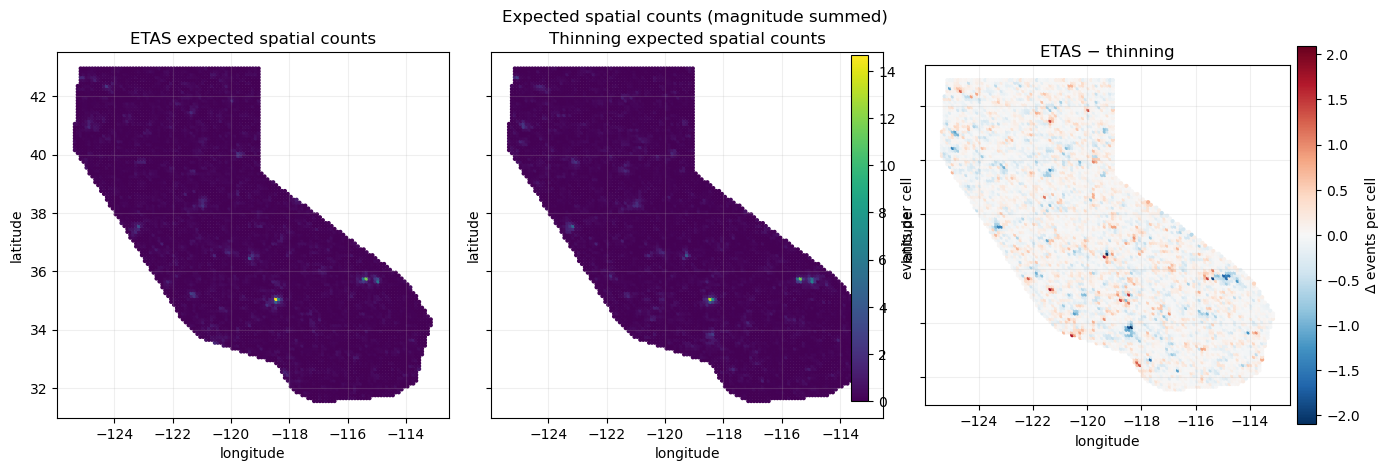

In [28]:
# Spatially aggregated expected rate per cell (M>=min magnitude), ETAS vs thinning.
etas_spatial = etas_expected.spatial_counts()
thin_spatial = thin_expected.spatial_counts()
lons, lats = csep_region.midpoints().T

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
vmax = max(etas_spatial.max(), thin_spatial.max())

sc0 = axes[0].scatter(lons, lats, c=etas_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[0].set_title("ETAS expected spatial counts")
axes[1].scatter(lons, lats, c=thin_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[1].set_title("Thinning expected spatial counts")

diff = etas_spatial - thin_spatial
vabs = np.max(np.abs(diff))
sc2 = axes[2].scatter(
    lons,
    lats,
    c=diff,
    s=4,
    cmap="RdBu_r",
    vmin=-vabs,
    vmax=vabs,
)
axes[2].set_title("ETAS − thinning")

for ax in axes:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

fig.colorbar(sc0, ax=axes[:2], fraction=0.03, pad=0.02, label="events per cell")
fig.colorbar(sc2, ax=axes[2], fraction=0.05, pad=0.02, label="Δ events per cell")
fig.suptitle("Expected spatial counts (magnitude summed)", fontsize=12)
fig.tight_layout()
plt.show()


## Spatial distribution for selected magnitude bin(s)

`expected_rates.data` has shape `(n_spatial, n_magnitude)`. Column `j` is the **expected event count per spatial cell** in magnitude bin `[m_j, m_j + Δm)`.

Summing column `j` over space recovers the marginal entry from `magnitude_counts()[j]` — the map below is the spatial **decomposition** of that marginal, not a different distribution.

M∈[4.0, 4.1): spatial sum ETAS=85.0192 (marginal=85.0192), thinning=84.6923 (marginal=84.6923)
M∈[5.0, 5.1): spatial sum ETAS=8.4231 (marginal=8.4231), thinning=8.8077 (marginal=8.8077)
M∈[6.0, 6.1): spatial sum ETAS=0.7115 (marginal=0.7115), thinning=0.9615 (marginal=0.9615)


/tmp/ipykernel_1351198/397523786.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


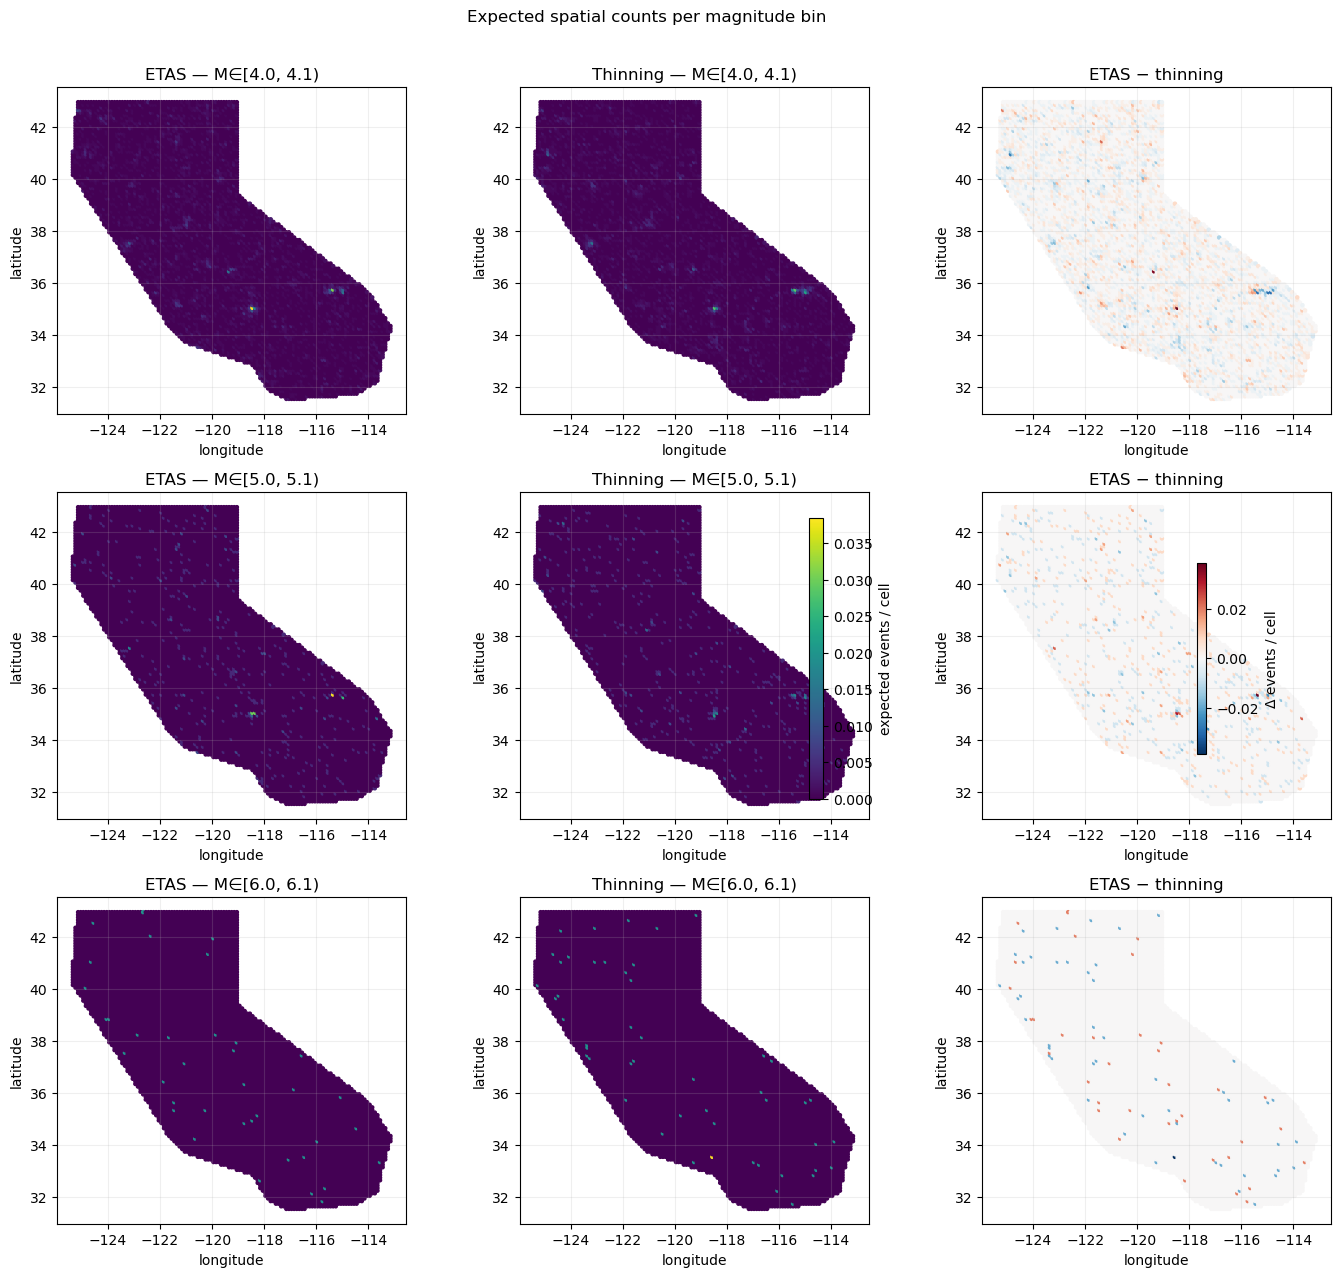

In [29]:
# --- configure magnitude bin(s) to map ---
# Left edges from CSEP bins (e.g. 4.0 → events with 4.0 ≤ M < 4.1 when dmw=0.1).
MAG_BIN_LEFT_EDGES: list[float] | None = [4.0, 5.0, 6.0]

# Used only when MAG_BIN_LEFT_EDGES is None: sum all bins whose left edge lies in [lo, hi].
MAG_RANGE: tuple[float, float] = (4.0, 5.0)


def _mag_bin_indices(mag_left_edges: np.ndarray, targets: list[float]) -> list[int]:
    idx = []
    for m in targets:
        j = int(np.searchsorted(mag_left_edges, m, side="left"))
        if j >= len(mag_left_edges) or not np.isclose(mag_left_edges[j], m):
            raise ValueError(f"{m} is not a CSEP magnitude bin left edge; nearest bins: {mag_left_edges[max(j-1,0):j+2]}")
        idx.append(j)
    return idx


def expected_spatial_for_mag_bins(expected, mag_indices: list[int]) -> np.ndarray:
    """Sum expected spatial counts over the selected magnitude columns."""
    if not mag_indices:
        return np.zeros(expected.data.shape[0])
    return expected.data[:, mag_indices].sum(axis=1)


mag_left = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_left[1] - mag_left[0]

if MAG_BIN_LEFT_EDGES is not None:
    mag_targets = MAG_BIN_LEFT_EDGES
else:
    lo, hi = MAG_RANGE
    mag_targets = [m for m in mag_left if lo <= m <= hi]
    if not mag_targets:
        raise ValueError(f"No CSEP bins in MAG_RANGE={MAG_RANGE}")

mag_indices = _mag_bin_indices(mag_left, mag_targets)
lons, lats = csep_region.midpoints().T

n_rows = len(mag_targets)
fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4.2 * n_rows), squeeze=False)

for row, (mag_edge, mag_idx) in enumerate(zip(mag_targets, mag_indices)):
    etas_slice = expected_spatial_for_mag_bins(etas_expected, [mag_idx])
    thin_slice = expected_spatial_for_mag_bins(thin_expected, [mag_idx])
    diff_slice = etas_slice - thin_slice

    vmax = max(etas_slice.max(), thin_slice.max(), 1e-12)
    vabs = max(np.abs(diff_slice).max(), 1e-12)

    sc0 = axes[row, 0].scatter(lons, lats, c=etas_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 0].set_title(f"ETAS — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    axes[row, 1].scatter(lons, lats, c=thin_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 1].set_title(f"Thinning — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    sc2 = axes[row, 2].scatter(
        lons, lats, c=diff_slice, s=5, cmap="RdBu_r", vmin=-vabs, vmax=vabs,
    )
    axes[row, 2].set_title("ETAS − thinning")

    for ax in axes[row]:
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    # Marginal check: sum over space == magnitude_counts()[bin]
    print(
        f"M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f}): "
        f"spatial sum ETAS={etas_slice.sum():.4f} (marginal={etas_expected.magnitude_counts()[mag_idx]:.4f}), "
        f"thinning={thin_slice.sum():.4f} (marginal={thin_expected.magnitude_counts()[mag_idx]:.4f})"
    )

fig.colorbar(sc0, ax=axes[:, :2].ravel().tolist(), fraction=0.02, pad=0.02, label="expected events / cell")
fig.colorbar(sc2, ax=axes[:, 2].ravel().tolist(), fraction=0.03, pad=0.02, label="Δ events / cell")
fig.suptitle("Expected spatial counts per magnitude bin", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()
